In [1]:
import sys
from pathlib import Path

# Add project root to sys.path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
from functions.utils import *

import matplotlib.pyplot as plt

import pickle

In [25]:
FLIGHT_CONTEXTS = ["CRUISE", "TAKEOFF", "CLIMB1", "CLIMB2"] 


SENSOR_SHORT_NAMES = ["HPC_Tin", "LPT_Tin", "HPC_Pout_st"]


INDICATORS_TO_ESTIMATE = [
    "deg_CmpFan_s_mapWc_in",   # Fan mass flow
    "deg_CmpH_s_mapEff_in",    # HPC efficiency
    "deg_TrbH_s_mapEff_in",    # HPT efficiency
]


#--------------------------------------------------------------------------------------------------------------
NOISE_COV_PATH = "../data/noise_covariances.pkl"

# Sensor order in noise covariance matrices (6x6)
NOISE_SENSOR_ORDER = ["HP_Nmech", "HPC_Tout", "HPC_Tin", "LPT_Tin", "Fuel_flow", "HPC_Pout_st"]

NOISE_COV_MAP = {
    "CRUISE": "Cruise_noise_covariance",
    "TAKEOFF": "Takeoff_noise_covariance",
    "CLIMB1": "Climb1_noise_covariance",
    "CLIMB2": "Climb2_noise_covariance",
}



ALL_CONTEXTS = ["CRUISE",  "TAKEOFF", "CLIMB1", "CLIMB2"]
ALL_SENSORS = ["HPC_Tin", "LPT_Tin", "HPC_Pout_st"]


# 1. Generate Data

In [14]:
%%time
# Generate data using states from existing file
df_synthetic = generate_multicontext_synthetic_data_from_file(
    csv_path="../data/Cie_0_Engine0.csv",
    flight_contexts=["CRUISE", "TAKEOFF", "CLIMB1", "CLIMB2"],
    sensor_short_names=["HPC_Tin", "LPT_Tin", "HPC_Pout_st"],
    n_samples=None # Or None for all rows
)

# Save
df_synthetic.to_csv("../data/synthetic_data.csv", index=False)

Loaded 1000 rows from ../data/Cie_0_Engine0.csv
Using 1000 samples
Contexts: ['CRUISE', 'TAKEOFF', 'CLIMB1', 'CLIMB2']
Sensors: ['HPC_Tin', 'LPT_Tin', 'HPC_Pout_st']
  Generated 20/1000 samples
  Generated 40/1000 samples
  Generated 60/1000 samples
  Generated 80/1000 samples
  Generated 100/1000 samples
  Generated 120/1000 samples
  Generated 140/1000 samples
  Generated 160/1000 samples
  Generated 180/1000 samples
  Generated 200/1000 samples
  Generated 220/1000 samples
  Generated 240/1000 samples
  Generated 260/1000 samples
  Generated 280/1000 samples
  Generated 300/1000 samples
  Generated 320/1000 samples
  Generated 340/1000 samples
  Generated 360/1000 samples
  Generated 380/1000 samples
  Generated 400/1000 samples
  Generated 420/1000 samples
  Generated 440/1000 samples
  Generated 460/1000 samples
  Generated 480/1000 samples
  Generated 500/1000 samples
  Generated 520/1000 samples
  Generated 540/1000 samples
  Generated 560/1000 samples
  Generated 580/1000 sampl

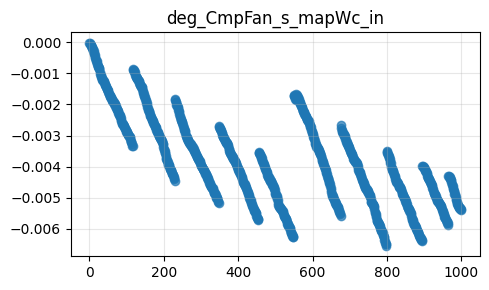

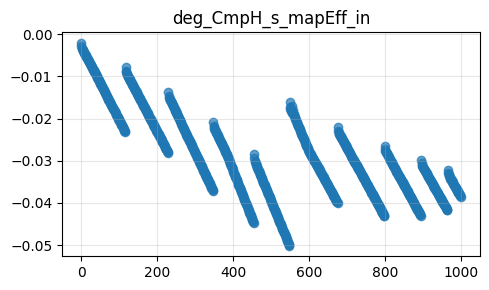

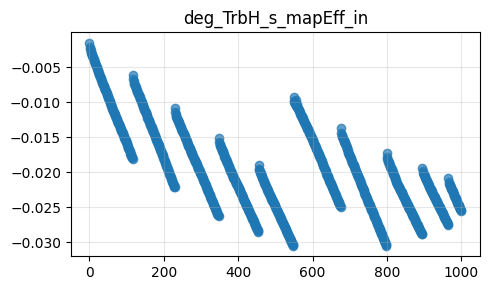

In [15]:
scatter_each_column (df_synthetic)

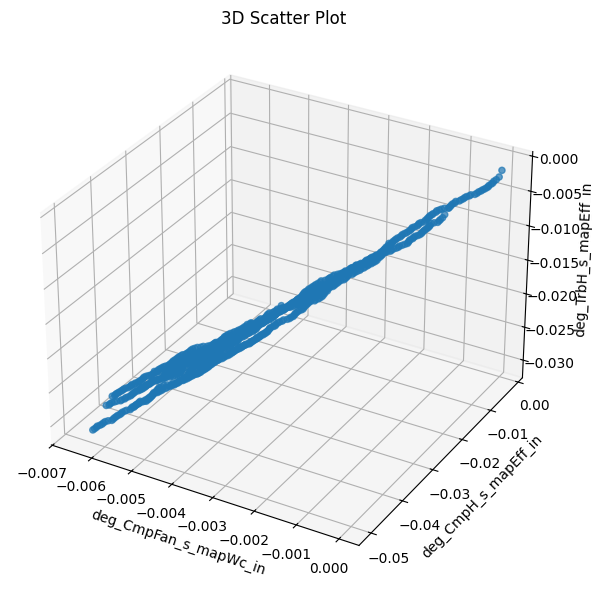

In [17]:
plot_3d_first_three(df_synthetic, INDICATORS_TO_ESTIMATE)

## 2.plot trajectory

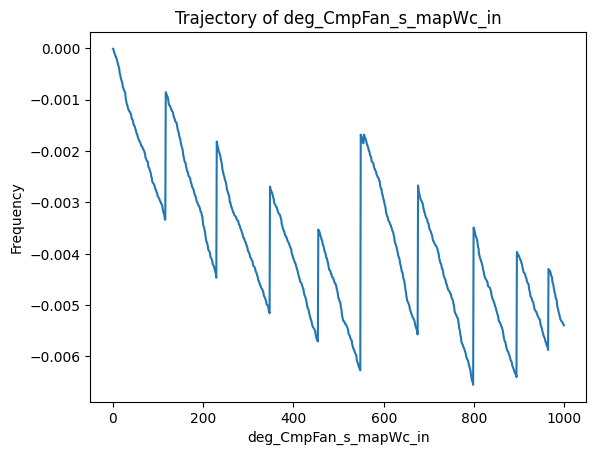

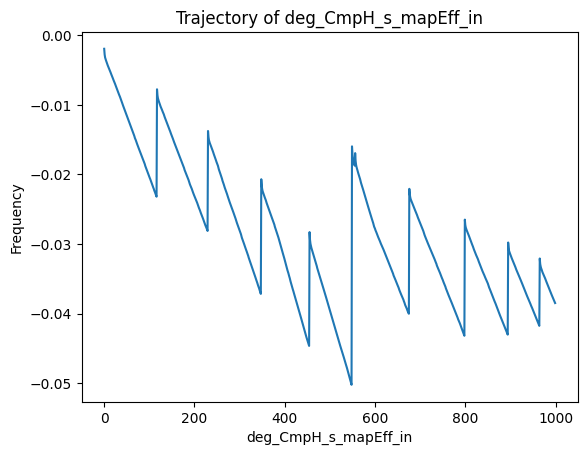

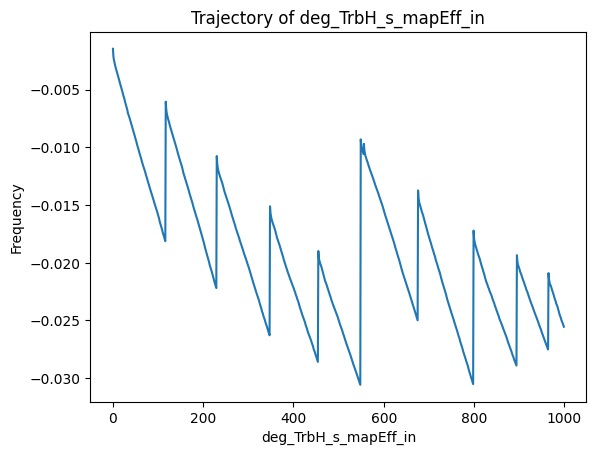

In [16]:
## plot trajectory

numeric_cols1 = df_synthetic.columns

for col in INDICATORS_TO_ESTIMATE:
 plt.figure()
 df_synthetic[col].plot()
 plt.title(f"Trajectory of {col}")
 plt.xlabel(col)
 plt.ylabel("Frequency")
 plt.show()

## 3.Generate with random uniform

It is also possible to run the random uniform version



In [18]:
# df_synthetic = generate_multicontext_synthetic_data_ru(
#     n_samples=100,
#     flight_contexts=FLIGHT_CONTEXTS,
#     sensor_short_names=SENSOR_SHORT_NAMES,
#     seed=42
# )


# print("\nSample of synthetic data:")
# display_cols = ['sample_id'] + INDICATORS_TO_ESTIMATE[:2]
# for ctx in FLIGHT_CONTEXTS[:2]:
#     display_cols.append(f'{ctx}_DECKSMR{SENSOR_SHORT_NAMES[0]}')
# print(df_synthetic[display_cols].head())


# scatter_each_column (df_synthetic)

## 4.Add Noise to to sensor measurements

In [26]:
# Load noise covariances
with open(NOISE_COV_PATH, 'rb') as f:
    NOISE_COVARIANCES = pickle.load(f)
    

print("Noise covariances loaded:")
for ctx, key in NOISE_COV_MAP.items():
    cov = NOISE_COVARIANCES[key]
    std_devs = np.sqrt(np.diag(cov))
    print(f"  {ctx}: std_devs = {std_devs}")

    

Noise covariances loaded:
  CRUISE: std_devs = [1.20e-01 3.60e+00 5.00e-02 4.60e-01 2.16e-04 4.00e+02]
  TAKEOFF: std_devs = [2.0e-01 3.3e+00 5.0e-02 6.0e-01 7.8e-04 1.0e+03]
  CLIMB1: std_devs = [2.0e-01 3.3e+00 5.0e-02 6.0e-01 7.8e-04 1.0e+03]
  CLIMB2: std_devs = [2.0e-01 3.3e+00 5.0e-02 6.0e-01 7.8e-04 1.0e+03]


In [33]:
NOISE_COV_MAP

{'CRUISE': 'Cruise_noise_covariance',
 'TAKEOFF': 'Takeoff_noise_covariance',
 'CLIMB1': 'Climb1_noise_covariance',
 'CLIMB2': 'Climb2_noise_covariance'}

In [27]:
CLEAN_DATA_PATH = "../data/synthetic_data.csv"
# Load clean data
df_clean = pd.read_csv(CLEAN_DATA_PATH)
print(f"Loaded {len(df_clean)} rows from {CLEAN_DATA_PATH}")

Loaded 1000 rows from ../data/synthetic_data.csv


In [28]:
# Generate noisy version of data

df_noisy = add_noise_to_data(df_clean, ALL_CONTEXTS, ALL_SENSORS, seed=123)

# Save noisy data
noisy_data_path = CLEAN_DATA_PATH.replace('.csv', '_noisy.csv')
df_noisy.to_csv(noisy_data_path, index=False)
print(f"Noisy data saved to: {noisy_data_path}")

# Show noise effect
print("\nNoise effect sample (row 0, CRUISE):")
for s in ALL_SENSORS:
    col = f'CRUISE_DECKSMR{s}'
    clean_val = df_clean.loc[0, col]
    noisy_val = df_noisy.loc[0, col]
    diff = noisy_val - clean_val
    print(f"  {s}: clean={clean_val:.4f}, noisy={noisy_val:.4f}, noise={diff:.4f}")

Noisy data saved to: ../data/synthetic_data_noisy.csv

Noise effect sample (row 0, CRUISE):
  HPC_Tin: clean=336.0642, noisy=336.0353, noise=-0.0289
  LPT_Tin: clean=1123.0515, noisy=1123.1817, noise=0.1302
  HPC_Pout_st: clean=1377933.0900, noisy=1377498.8378, noise=-434.2522


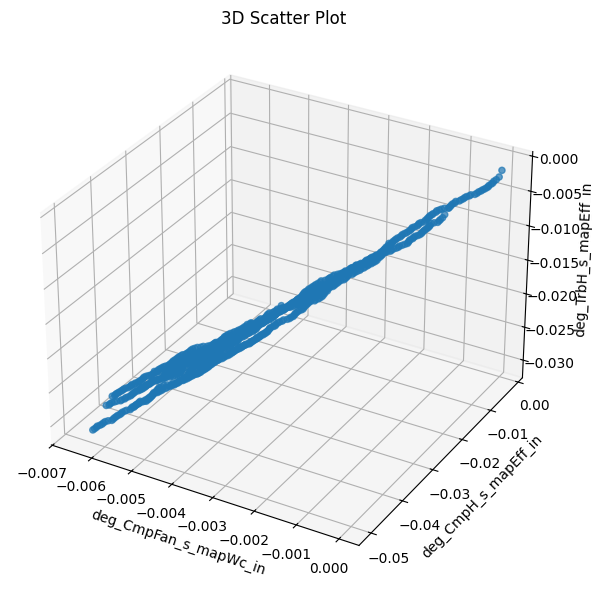

In [23]:
plot_3d_first_three(df_noisy, INDICATORS_TO_ESTIMATE)

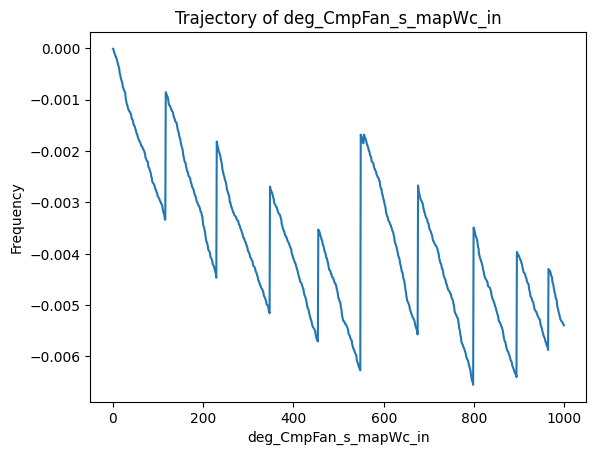

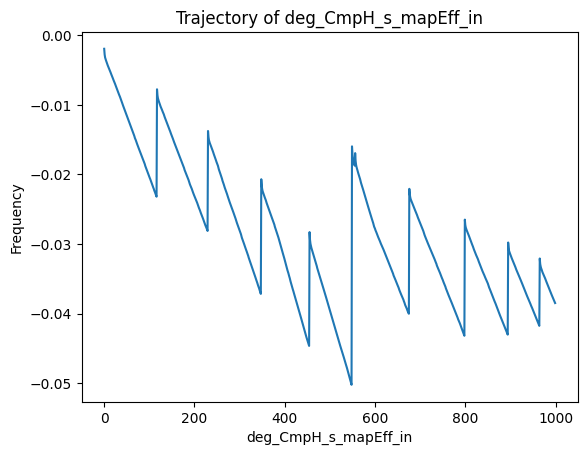

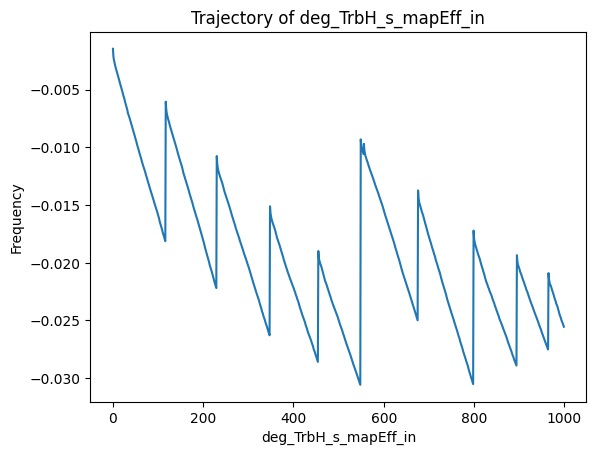

In [29]:
## plot trajectory

numeric_cols1 = df_noisy.columns

for col in INDICATORS_TO_ESTIMATE:
 plt.figure()
 df_noisy[col].plot()
 plt.title(f"Trajectory of {col}")
 plt.xlabel(col)
 plt.ylabel("Frequency")
 plt.show()

# This is done with already generated data

Let us check which context has more noise

In [30]:
CLEAN_DATA_PATH = "../data/synthetic_data.csv"
# Load clean data
df_clean = pd.read_csv(CLEAN_DATA_PATH)
print(f"Loaded {len(df_clean)} rows from {CLEAN_DATA_PATH}")


noisy_data_path =  "../data/synthetic_data_noisy.csv"

# Load clean data
df_noisy = pd.read_csv(noisy_data_path )
print(f"Loaded {len(df_noisy)} rows from {noisy_data_path }")

Loaded 1000 rows from ../data/synthetic_data.csv
Loaded 1000 rows from ../data/synthetic_data_noisy.csv


In [31]:
# Show noise effect
print("\nNoise effect sample (row 0, CRUISE):")
for s in ALL_SENSORS:
    col = f'CRUISE_DECKSMR{s}'
    clean_val = df_clean.loc[0, col]
    noisy_val = df_noisy.loc[0, col]
    diff = noisy_val - clean_val
    print(f"  {s}: clean={clean_val:.4f}, noisy={noisy_val:.4f}, noise={diff:.4f}")


Noise effect sample (row 0, CRUISE):
  HPC_Tin: clean=336.0642, noisy=336.0353, noise=-0.0289
  LPT_Tin: clean=1123.0515, noisy=1123.1817, noise=0.1302
  HPC_Pout_st: clean=1377933.0900, noisy=1377498.8378, noise=-434.2522


In [32]:
def print_noise_sample(df_clean, df_noisy, row_idx, context, sensors):
    print(f"\nNoise effect sample (row {row_idx}, {context}):")
    for s in sensors:
        col = f'{context}_DECKSMR{s}'
        clean_val = df_clean.loc[row_idx, col]
        noisy_val = df_noisy.loc[row_idx, col]
        diff = noisy_val - clean_val
        print(f"  {s:<15} clean={clean_val:.4f}  noisy={noisy_val:.4f}  noise={diff:+.4f}")


print_noise_sample(df_clean, df_noisy, row_idx=0, context="CRUISE", sensors=ALL_SENSORS)



Noise effect sample (row 0, CRUISE):
  HPC_Tin         clean=336.0642  noisy=336.0353  noise=-0.0289
  LPT_Tin         clean=1123.0515  noisy=1123.1817  noise=+0.1302
  HPC_Pout_st     clean=1377933.0900  noisy=1377498.8378  noise=-434.2522


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_noise_by_context(df_clean, df_noisy, contexts, sensors):
    noise_data = []

    for ctx in contexts:
        for s in sensors:
            col = f'{ctx}_DECKSMR{s}'
            noise = df_noisy[col] - df_clean[col]
            for v in noise.values:
                noise_data.append({
                    "context": ctx,
                    "sensor": s,
                    "noise": v
                })

    noise_df = pd.DataFrame(noise_data)

    plt.figure(figsize=(10, 5))
    noise_df.boxplot(column="noise", by="context", grid=True)
    plt.title("Noise Distribution per Context")
    plt.suptitle("")
    plt.ylabel("Noise (noisy − clean)")
    plt.xlabel("Flight context")
    plt.tight_layout()
    plt.show()

    return noise_df


<Figure size 1000x500 with 0 Axes>

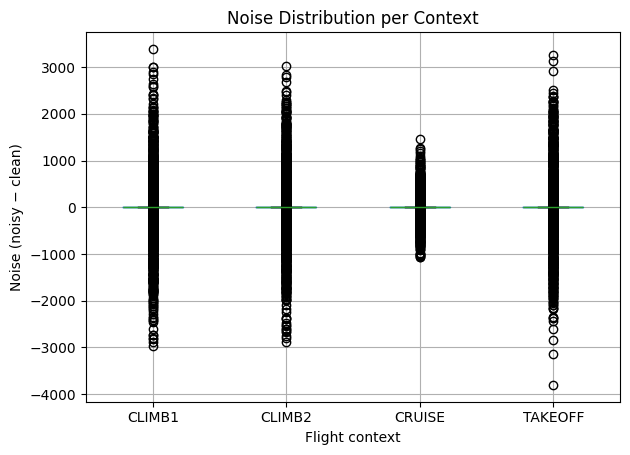

In [34]:
noisy_df = plot_noise_by_context(
    df_clean,
    df_noisy,
    contexts=["CRUISE", "TAKEOFF", "CLIMB1", "CLIMB2"],
    sensors=ALL_SENSORS
)


In [35]:
noisy_df

,context,sensor,noise
0,CRUISE,HPC_Tin,-0.028930
1,CRUISE,HPC_Tin,-0.007003
2,CRUISE,HPC_Tin,0.087186
3,CRUISE,HPC_Tin,-0.020168
4,CRUISE,HPC_Tin,0.032103
...,...,...,...
11995,CLIMB2,HPC_Pout_st,-1028.678993
11996,CLIMB2,HPC_Pout_st,255.159952
11997,CLIMB2,HPC_Pout_st,742.617231
11998,CLIMB2,HPC_Pout_st,-1990.458358


---
The plot shows there is less noise at the CRUISE level.
---

In [36]:
import seaborn as sns

def plot_noise_heatmap(df_clean, df_noisy, contexts, sensors):
    heatmap_data = []

    for ctx in contexts:
        for s in sensors:
            col = f'{ctx}_DECKSMR{s}'
            mean_abs_noise = np.mean(np.abs(df_noisy[col] - df_clean[col]))
            heatmap_data.append({
                "context": ctx,
                "sensor": s,
                "mean_abs_noise": mean_abs_noise
            })

    hm_df = pd.DataFrame(heatmap_data)
    pivot = hm_df.pivot(index="sensor", columns="context", values="mean_abs_noise")

    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt=".2e", cmap="Reds")
    plt.title("Mean Absolute Noise per Sensor and Context")
    plt.tight_layout()
    plt.show()

    return hm_df


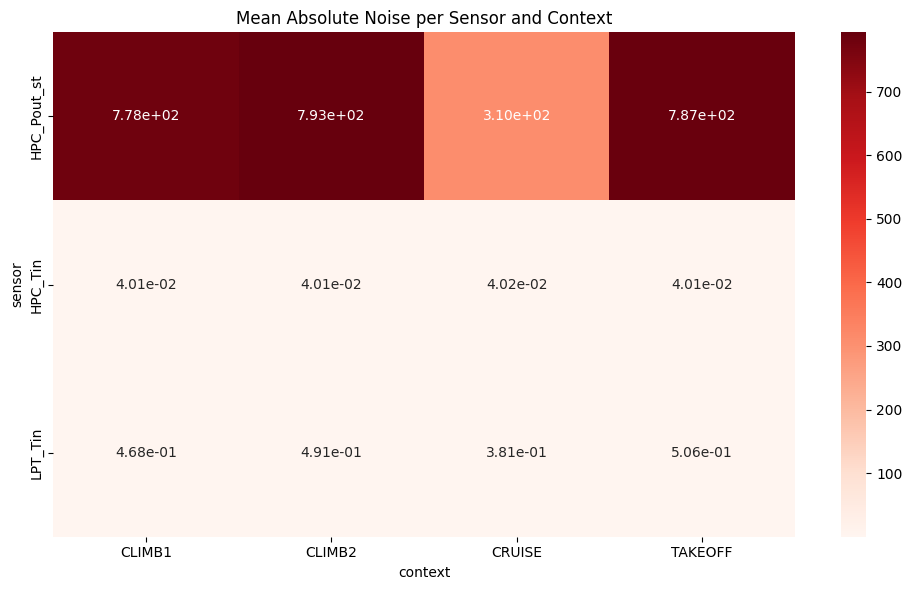

In [37]:
hm_df = plot_noise_heatmap(
    df_clean,
    df_noisy,
    contexts=["CRUISE", "TAKEOFF", "CLIMB1", "CLIMB2"],
    sensors=ALL_SENSORS
)

In [39]:
hm_df

,context,sensor,mean_abs_noise
0,CRUISE,HPC_Tin,0.040180
1,CRUISE,LPT_Tin,0.381274
2,CRUISE,HPC_Pout_st,310.211064
3,TAKEOFF,HPC_Tin,0.040104
4,TAKEOFF,LPT_Tin,0.505714
5,TAKEOFF,HPC_Pout_st,787.080465
6,CLIMB1,HPC_Tin,0.040099
7,CLIMB1,LPT_Tin,0.467826
8,CLIMB1,HPC_Pout_st,777.863867
9,CLIMB2,HPC_Tin,0.040104
